In [1]:
# ==========================================
# CELL 1 - IMPORT LIBRARY
# ==========================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.preprocessing import MinMaxScaler
from sklearn.neighbors import KNeighborsRegressor
from sklearn.model_selection import TimeSeriesSplit
from sklearn.decomposition import PCA

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

In [2]:
# ==========================================
# CELL 2 - LOAD DATA
# ==========================================

df = pd.read_excel("datahujan2021-2025.xlsx")

df.columns = df.columns.str.lower()

df.rename(columns={

    'temp_avg_c': 'TAVG',
    'temp_max_c': 'TX',
    'temp_min_c': 'TN',
    'rainfall_mm': 'RR',
    'sunshine_h': 'SS',
    'rel_humidity_avg_pc': 'RH_AVG',
    'wind_speed_avg_km_h': 'FF_AVG',
    'wind_speed_max_knots': 'FF_X'

}, inplace=True)

# convert tanggal
df['tanggal'] = pd.to_datetime(
    df['data_timestamp']
)

# group harian
df = df.groupby('tanggal').mean(
    numeric_only=True
).reset_index()

In [3]:
# ==========================================
# CELL 3 - FEATURE ENGINEERING
# ==========================================

# ==========================================
# TARGET REGRESI
# ==========================================

df['RR_NEXT'] = df['RR'].shift(-1)

# ==========================================
# FITUR KALENDER
# ==========================================

df['DAYOFYEAR'] = df['tanggal'].dt.dayofyear

df['MONTH'] = df['tanggal'].dt.month

# ==========================================
# FITUR ROLLING WINDOW
# ==========================================

df['TAVG_3D'] = df['TAVG'].rolling(3).mean()

df['RR_3D'] = df['RR'].rolling(3).sum()

df['RH_3D'] = df['RH_AVG'].rolling(3).mean()

# ==========================================
# LAG FEATURE
# ==========================================

df['RR_LAG_1'] = df['RR'].shift(1)

df['RR_LAG_7'] = df['RR'].shift(7)

df['RR_LAG_14'] = df['RR'].shift(14)

# ==========================================
# ROLLING STATISTIK
# ==========================================

df['RR_MEAN_7'] = df['RR'].rolling(7).mean()

df['RR_STD_7'] = df['RR'].rolling(7).std()

df['RR_MEAN_30'] = df['RR'].rolling(30).mean()

df['RR_STD_30'] = df['RR'].rolling(30).std()

# ==========================================
# DELTA FEATURE
# ==========================================

df['TAVG_DIFF'] = (

    df['TAVG']
    - df['TAVG'].shift(1)
)

df['RH_DIFF'] = (

    df['RH_AVG']
    - df['RH_AVG'].shift(1)
)

df['RR_DIFF'] = (

    df['RR']
    - df['RR'].shift(1)
)

# ==========================================
# HAPUS NaN
# ==========================================

df = df.dropna().reset_index(drop=True)

df.head()

,tanggal,wmo_id,tahun,bulan,TAVG,TX,TN,RR,SS,RH_AVG,...,RR_LAG_1,RR_LAG_7,RR_LAG_14,RR_MEAN_7,RR_STD_7,RR_MEAN_30,RR_STD_30,TAVG_DIFF,RH_DIFF,RR_DIFF
0,2021-01-30,96935.0,2021.0,1.0,26.5750,28.60,25.20,0.0,3.15,85.250,...,0.8,33.50,0.00,16.278571,25.208379,11.188333,16.604568,-1.2000,5.625,-0.8
1,2021-01-31,96935.0,2021.0,1.0,27.3875,30.90,25.00,1.0,0.00,84.375,...,0.0,29.25,0.00,12.242857,25.046431,9.838333,15.675556,0.8125,-0.875,1.0
2,2021-02-01,96935.0,2021.0,2.0,27.8875,32.75,25.35,24.6,4.90,82.625,...,1.0,15.30,0.00,13.571429,25.478551,10.658333,15.786190,0.5000,-1.750,23.6
3,2021-02-02,96935.0,2021.0,2.0,28.7250,32.55,25.80,6.3,5.25,79.125,...,24.6,0.00,4.00,14.471429,25.026517,10.581667,15.802109,0.8375,-3.500,-18.3
4,2021-02-03,96935.0,2021.0,2.0,27.9000,31.10,25.15,0.5,6.70,82.500,...,6.3,67.65,0.15,4.878571,8.953950,10.135000,15.894193,-0.8250,3.375,-5.8


In [ ]:
# ==========================================
# CELL 4 - FEATURE & TARGET
# ==========================================

features = [

    # meteorologi
    'TAVG',
    'TX',
    'TN',
    'RH_AVG',
    'SS',
    'FF_X',
    'FF_AVG',


    'TAVG_3D',
    'RR_3D',
    'RH_3D',

    'DAYOFYEAR',
    'MONTH',

    # lag
    'RR_LAG_1',
    'RR_LAG_7',
    'RR_LAG_14',

    # rolling
    'RR_MEAN_7',
    'RR_STD_7',

    'RR_MEAN_30',
    'RR_STD_30',

    # delta
    'TAVG_DIFF',
    'RH_DIFF',
    'RR_DIFF'
]

X = df[features]

y = df['RR_NEXT']

print("Jumlah Feature:", len(features))

Jumlah Feature: 22


In [5]:
# ==========================================
# CELL 5 - KATEGORI HUJAN
# ==========================================

def kategori_hujan(rr):

    if rr < 0.5:
        return 0

    elif rr <= 20:
        return 1

    elif rr <= 50:
        return 2

    else:
        return 3

In [6]:
# ==========================================
# CELL 6 - TRAINING
# ==========================================

ratios = [0.6, 0.7, 0.8, 0.9]

k_list = [3,5,7,9]

metrics = [
    'euclidean',
    'manhattan',
    'minkowski'
]

results = []

for ratio in ratios:

    print(f"\n===== RATIO {ratio} =====")

    split = int(len(X) * ratio)

    X_train = X.iloc[:split]
    X_test = X.iloc[split:]

    y_train = y.iloc[:split]
    y_test = y.iloc[split:]

    # ======================================
    # SCALING
    # ======================================

    scaler = MinMaxScaler()

    X_train_s = scaler.fit_transform(
        X_train
    )

    X_test_s = scaler.transform(
        X_test
    )

    # ======================================
    # PCA
    # ======================================

    pca = PCA(
        n_components=0.95
    )

    X_train_pca = pca.fit_transform(
        X_train_s
    )

    X_test_pca = pca.transform(
        X_test_s
    )

    print(
        "Jumlah PCA Component:",
        pca.n_components_
    )

    # ======================================
    # TIMESERIES CV
    # ======================================

    tscv = TimeSeriesSplit(
        n_splits=5
    )

    for k in k_list:

        for metric in metrics:

            cv_mae = []
            cv_rmse = []

            cv_acc = []
            cv_prec = []
            cv_rec = []
            cv_f1 = []

            # ==================================
            # CROSS VALIDATION
            # ==================================

            for train_idx, val_idx in tscv.split(X_train_pca):

                X_cv_train = X_train_pca[
                    train_idx
                ]

                X_cv_val = X_train_pca[
                    val_idx
                ]

                y_cv_train = y_train.iloc[
                    train_idx
                ]

                y_cv_val = y_train.iloc[
                    val_idx
                ]

                model = KNeighborsRegressor(

                    n_neighbors=k,

                    metric=metric,

                    weights='distance'
                )

                model.fit(
                    X_cv_train,
                    y_cv_train
                )

                pred_cv = model.predict(
                    X_cv_val
                )

                # ==============================
                # REGRESSION
                # ==============================

                mae = mean_absolute_error(
                    y_cv_val,
                    pred_cv
                )

                rmse = np.sqrt(
                    mean_squared_error(
                        y_cv_val,
                        pred_cv
                    )
                )

                # ==============================
                # CLASSIFICATION
                # ==============================

                y_true_cat = y_cv_val.apply(
                    kategori_hujan
                )

                y_pred_cat = pd.Series(
                    pred_cv
                ).apply(
                    kategori_hujan
                )

                acc = accuracy_score(
                    y_true_cat,
                    y_pred_cat
                )

                prec = precision_score(
                    y_true_cat,
                    y_pred_cat,
                    average='weighted',
                    zero_division=0
                )

                rec = recall_score(
                    y_true_cat,
                    y_pred_cat,
                    average='weighted',
                    zero_division=0
                )

                f1 = f1_score(
                    y_true_cat,
                    y_pred_cat,
                    average='weighted',
                    zero_division=0
                )

                cv_mae.append(mae)
                cv_rmse.append(rmse)

                cv_acc.append(acc)
                cv_prec.append(prec)
                cv_rec.append(rec)
                cv_f1.append(f1)

            # ==================================
            # FINAL TEST
            # ==================================

            final_model = KNeighborsRegressor(

                n_neighbors=k,

                metric=metric,

                weights='distance'
            )

            final_model.fit(
                X_train_pca,
                y_train
            )

            pred_test = final_model.predict(
                X_test_pca
            )

            # ==================================
            # TEST REGRESSION
            # ==================================

            test_mae = mean_absolute_error(
                y_test,
                pred_test
            )

            test_rmse = np.sqrt(
                mean_squared_error(
                    y_test,
                    pred_test
                )
            )

            # ==================================
            # TEST CLASSIFICATION
            # ==================================

            y_test_cat = y_test.apply(
                kategori_hujan
            )

            y_pred_cat = pd.Series(
                pred_test
            ).apply(
                kategori_hujan
            )

            test_acc = accuracy_score(
                y_test_cat,
                y_pred_cat
            )

            test_prec = precision_score(
                y_test_cat,
                y_pred_cat,
                average='weighted',
                zero_division=0
            )

            test_rec = recall_score(
                y_test_cat,
                y_pred_cat,
                average='weighted',
                zero_division=0
            )

            test_f1 = f1_score(
                y_test_cat,
                y_pred_cat,
                average='weighted',
                zero_division=0
            )

            # ==================================
            # SAVE RESULT
            # ==================================

            results.append({

                'ratio': ratio,

                'metric': metric,

                'k': k,

                'CV_MAE': np.mean(cv_mae),

                'CV_RMSE': np.mean(cv_rmse),

                'CV_Accuracy': np.mean(cv_acc),

                'CV_Precision': np.mean(cv_prec),

                'CV_Recall': np.mean(cv_rec),

                'CV_F1': np.mean(cv_f1),

                'TEST_MAE': test_mae,

                'TEST_RMSE': test_rmse,

                'TEST_Accuracy': test_acc,

                'TEST_Precision': test_prec,

                'TEST_Recall': test_rec,

                'TEST_F1': test_f1,

                'PCA_Component': pca.n_components_
            })
            
pd.set_option('display.float_format', '{:.2f}'.format)
df_results = pd.DataFrame(results)
df_results.to_excel("hasil_cell6.xlsx", index=False)
df_results


===== RATIO 0.6 =====
Jumlah PCA Component: 11

===== RATIO 0.7 =====
Jumlah PCA Component: 10

===== RATIO 0.8 =====
Jumlah PCA Component: 10

===== RATIO 0.9 =====
Jumlah PCA Component: 10


,ratio,metric,k,CV_MAE,CV_RMSE,CV_Accuracy,CV_Precision,CV_Recall,CV_F1,TEST_MAE,TEST_RMSE,TEST_Accuracy,TEST_Precision,TEST_Recall,TEST_F1,PCA_Component
0,0.60,euclidean,3,6.35,12.08,0.63,0.67,0.63,0.63,5.63,13.08,0.64,0.67,0.64,0.64,11
1,0.60,manhattan,3,6.56,12.31,0.61,0.67,0.61,0.62,5.83,12.98,0.63,0.67,0.63,0.64,11
2,0.60,minkowski,3,6.35,12.08,0.63,0.67,0.63,0.63,5.63,13.08,0.64,0.67,0.64,0.64,11
3,0.60,euclidean,5,5.98,11.30,0.62,0.68,0.62,0.62,5.52,12.43,0.62,0.69,0.62,0.63,11
4,0.60,manhattan,5,6.19,11.53,0.61,0.69,0.61,0.61,5.66,12.52,0.62,0.69,0.62,0.63,11
5,0.60,minkowski,5,5.98,11.30,0.62,0.68,0.62,0.62,5.52,12.43,0.62,0.69,0.62,0.63,11
6,0.60,euclidean,7,5.85,11.07,0.61,0.70,0.61,0.61,5.49,12.29,0.64,0.70,0.64,0.64,11
7,0.60,manhattan,7,6.16,11.35,0.58,0.69,0.58,0.58,5.56,12.18,0.62,0.70,0.62,0.63,11
8,0.60,minkowski,7,5.85,11.07,0.61,0.70,0.61,0.61,5.49,12.29,0.64,0.70,0.64,0.64,11
9,0.60,euclidean,9,5.81,10.87,0.60,0.71,0.60,0.60,5.46,12.22,0.64,0.70,0.64,0.64,11


In [7]:
print(df_results.columns.tolist())

['ratio', 'metric', 'k', 'CV_MAE', 'CV_RMSE', 'CV_Accuracy', 'CV_Precision', 'CV_Recall', 'CV_F1', 'TEST_MAE', 'TEST_RMSE', 'TEST_Accuracy', 'TEST_Precision', 'TEST_Recall', 'TEST_F1', 'PCA_Component']


In [8]:
# ==========================================
# CELL SUMMARY FINAL
# ==========================================

summary_results = []

# ==========================================
# LOOP RATIO
# ==========================================

for ratio in sorted(
    df_results['ratio'].unique()
):

    # ======================================
    # LOOP METRIC
    # ======================================

    for metric in sorted(
        df_results['metric'].unique()
    ):

        df_temp = df_results[

            (df_results['ratio'] == ratio)
            &
            (df_results['metric'] == metric)
        ]

        # ==================================
        # BEST MAE
        # ==================================

        best_mae = df_temp.loc[
            df_temp['TEST_MAE'].idxmin()
        ]

        # ==================================
        # BEST ACCURACY
        # ==================================

        best_acc = df_temp.loc[
            df_temp['TEST_Accuracy'].idxmax()
        ]

        # ==================================
        # SAVE SUMMARY
        # ==================================

        summary_results.append({

            'Ratio': ratio,

            'Metric': metric,

            # ==============================
            # BEST MAE
            # ==============================

            'Best_K_MAE': int(best_mae['k']),

            'TEST_MAE': round(
                best_mae['TEST_MAE'],
                4
            ),

            'TEST_RMSE': round(
                best_mae['TEST_RMSE'],
                4
            ),

            # ==============================
            # BEST ACCURACY
            # ==============================

            'Best_K_ACC': int(best_acc['k']),

            'TEST_Accuracy (%)': round(
                best_acc['TEST_Accuracy'] * 100,
                2
            ),

            'TEST_Precision': round(
                best_acc['TEST_Precision'],
                4
            ),

            'TEST_Recall': round(
                best_acc['TEST_Recall'],
                4
            ),

            'TEST_F1': round(
                best_acc['TEST_F1'],
                4
            ),

            # ==============================
            # PCA
            # ==============================

            'PCA_Component': int(
                best_acc['PCA_Component']
            )
        })

In [9]:
# ==========================================
# CELL 7 - BEST MAE
# ==========================================

print("=== BEST BY MAE ===")

best_mae = df_results.loc[
    df_results['TEST_MAE'].idxmin()
]
pd.set_option('display.float_format', '{:.2f}'.format)
print(best_mae)

=== BEST BY MAE ===
ratio                  0.90
metric            manhattan
k                         3
CV_MAE                 6.10
CV_RMSE               12.20
CV_Accuracy            0.61
CV_Precision           0.65
CV_Recall              0.61
CV_F1                  0.61
TEST_MAE               5.18
TEST_RMSE             11.37
TEST_Accuracy          0.69
TEST_Precision         0.74
TEST_Recall            0.69
TEST_F1                0.70
PCA_Component            10
Name: 37, dtype: object


In [10]:
# ==========================================
# CELL 8 - BEST ACCURACY
# ==========================================

print("=== BEST BY ACCURACY ===")

best_acc = df_results.loc[
    df_results['TEST_Accuracy'].idxmax()
]
pd.set_option('display.float_format', '{:.2f}'.format)
print(best_acc)

=== BEST BY ACCURACY ===
ratio                  0.70
metric            euclidean
k                         3
CV_MAE                 6.10
CV_RMSE               11.84
CV_Accuracy            0.62
CV_Precision           0.65
CV_Recall              0.62
CV_F1                  0.62
TEST_MAE               5.62
TEST_RMSE             12.23
TEST_Accuracy          0.71
TEST_Precision         0.74
TEST_Recall            0.71
TEST_F1                0.71
PCA_Component            10
Name: 12, dtype: object


In [ ]:
# ==========================================
# CELL 9 - CONFUSION MATRIX FUNCTION
# ==========================================

def plot_cm(best_row, title):

    ratio = best_row['ratio']

    metric = best_row['metric']

    k = int(best_row['k'])

    split = int(len(X) * ratio)

    X_train = X.iloc[:split]

    X_test = X.iloc[split:]

    y_train = y.iloc[:split]

    y_test = y.iloc[split:]

    # scaling
    scaler = MinMaxScaler()

    X_train_s = scaler.fit_transform(
        X_train
    )

    X_test_s = scaler.transform(
        X_test
    )

    # PCA
    pca = PCA(
        n_components=0.95
    )

    X_train_pca = pca.fit_transform(
        X_train_s
    )

    X_test_pca = pca.transform(
        X_test_s
    )

    # model
    model = KNeighborsRegressor(

        n_neighbors=k,

        metric=metric,

        weights='distance'
    )

    model.fit(
        X_train_pca,
        y_train
    )

    pred = model.predict(
        X_test_pca
    )

    y_test_cat = y_test.apply(
        kategori_hujan
    )

    y_pred_cat = pd.Series(pred).apply(
        kategori_hujan
    )

    cm = confusion_matrix(

        y_test_cat,

        y_pred_cat
    )

    plt.figure(figsize=(6,5))

    sns.heatmap(

        cm,

        annot=True,

        fmt='d',

        cmap='Blues'
    )

    plt.title(title)

    plt.xlabel("Predicted")

    plt.ylabel("Actual")

    plt.show()

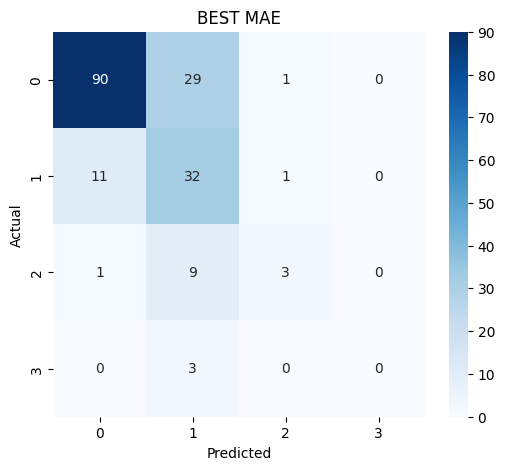

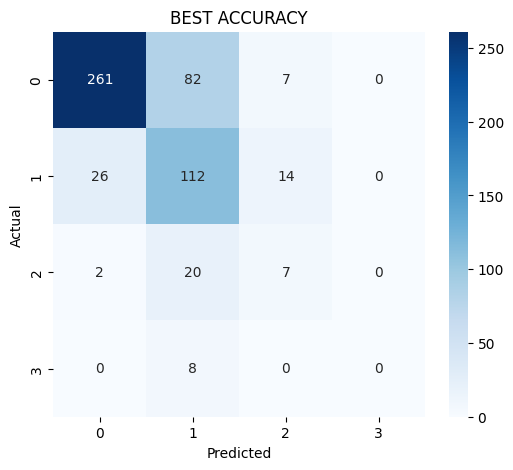

In [12]:
# ==========================================
# CELL 10 - PLOT CM
# ==========================================

plot_cm(
    best_mae,
    "BEST MAE"
)

plot_cm(
    best_acc,
    "BEST ACCURACY"
)

In [13]:
# ==========================================
# CELL 11 - SAVE MODEL TERBAIK
# ==========================================

ratio = best_mae['ratio']

metric = best_mae['metric']

k = int(best_mae['k'])

split = int(len(X) * ratio)

X_train = X.iloc[:split]

y_train = y.iloc[:split]

# scaling
scaler_final = MinMaxScaler()

X_train_s = scaler_final.fit_transform(
    X_train
)

# PCA
pca_final = PCA(
    n_components=0.95
)

X_train_pca = pca_final.fit_transform(
    X_train_s
)

# model
model_final = KNeighborsRegressor(

    n_neighbors=k,

    metric=metric,

    weights='distance'
)

model_final.fit(
    X_train_pca,
    y_train
)

print("✅ FINAL MODEL TRAINED")

✅ FINAL MODEL TRAINED


In [14]:
# ==========================================
# CELL 12 - SAVE MODEL
# ==========================================

joblib.dump(
    model_final,
    "model_hybrid_v5_1.pkl"
)

joblib.dump(
    scaler_final,
    "scaler_hybrid_v5_1.pkl"
)

joblib.dump(
    pca_final,
    "pca_hybrid_v5_1.pkl"
)

joblib.dump(
    features,
    "features_hybrid_v5_1.pkl"
)

print("✅ MODEL V5.1 BERHASIL DISIMPAN")

✅ MODEL V5.1 BERHASIL DISIMPAN


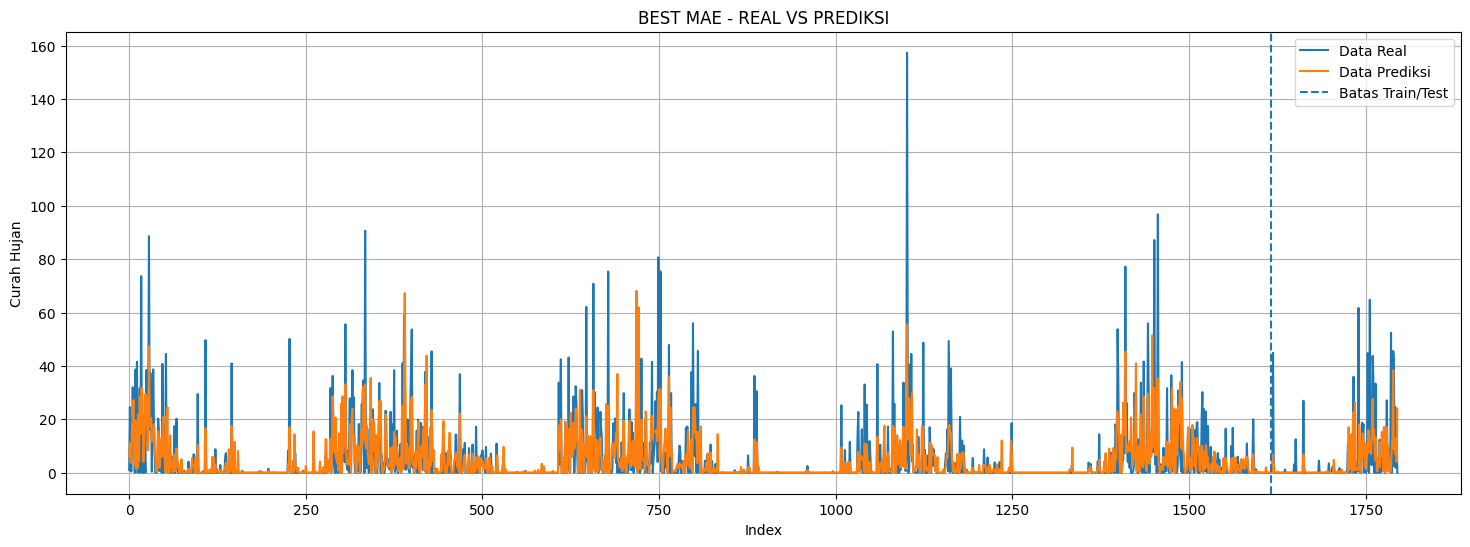

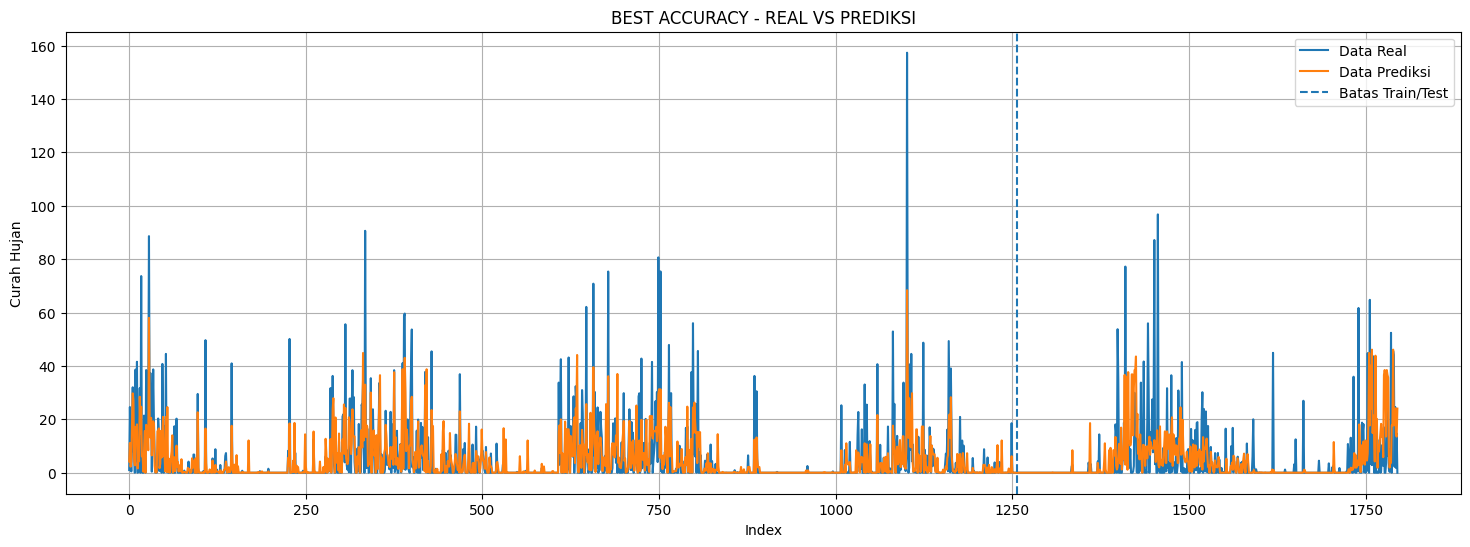

In [15]:
# ==========================================
# CELL TAMBAHAN - GRAFIK GABUNGAN
# REAL VS PREDIKSI
# ==========================================

def plot_combined(best_row, title):

    ratio = best_row['ratio']
    metric = best_row['metric']
    k = int(best_row['k'])

    split = int(len(X) * ratio)

    X_train = X.iloc[:split]
    X_test = X.iloc[split:]

    y_train = y.iloc[:split]
    y_test = y.iloc[split:]

    # ======================================
    # SCALING
    # ======================================

    scaler = MinMaxScaler()

    X_train_s = scaler.fit_transform(X_train)
    X_test_s = scaler.transform(X_test)

    # ======================================
    # PCA
    # ======================================

    pca = PCA(n_components=0.95)

    X_train_pca = pca.fit_transform(X_train_s)
    X_test_pca = pca.transform(X_test_s)

    # ======================================
    # MODEL
    # ======================================

    model = KNeighborsRegressor(
        n_neighbors=k,
        metric=metric
    )

    model.fit(X_train_pca, y_train)

    # ======================================
    # PREDIKSI
    # ======================================

    y_train_pred = model.predict(X_train_pca)
    y_test_pred = model.predict(X_test_pca)

    # ======================================
    # GABUNGKAN TRAIN + TEST
    # ======================================

    y_real = np.concatenate([y_train.values, y_test.values])
    y_pred = np.concatenate([y_train_pred, y_test_pred])

    # ======================================
    # PLOT
    # ======================================

    plt.figure(figsize=(18,6))

    plt.plot(
        y_real,
        label='Data Real'
    )

    plt.plot(
        y_pred,
        label='Data Prediksi'
    )

    # Garis pemisah train dan test
    plt.axvline(
        x=len(y_train),
        linestyle='--',
        label='Batas Train/Test'
    )

    plt.title(f'{title} - REAL VS PREDIKSI')
    plt.xlabel('Index')
    plt.ylabel('Curah Hujan')

    plt.legend()
    plt.grid(True)

    plt.show()


# ==========================================
# BEST MAE
# ==========================================

plot_combined(
    best_mae,
    "BEST MAE"
)

# ==========================================
# BEST ACCURACY
# ==========================================

plot_combined(
    best_acc,
    "BEST ACCURACY"
)